In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_squared_error, r2_score, mean_squared_log_error
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
palette_color = sns.color_palette("pastel")

In [2]:
df_train = pd.read_csv('dataset/raw/train.csv')
df_train.head()

,ID,Severity,Start_Time,End_Time,Latitude,Longitude,Distance(mi),Description,Street,City,...,Visibility(mi),Weather_Condition,Amenity,Crossing,Junction,Railway,Station,Stop,Traffic_Signal,Sunrise_Sunset
0,A-4081224,4,2022-03-18 06:55:00,2022-03-18 11:55:00,36.081864,-79.080223,0.039,The road is closed near St Mary's Rd.,St Marys Rd,Hillsborough,...,NaN,NaN,False,False,False,False,False,False,False,Night
1,A-4338502,2,2023-01-29 16:35:00,2023-01-29 17:53:04,38.927944,-121.056469,0.014,Incident on BOWMAN RD near LUTHER RD Drive wit...,Bowman Rd,Auburn,...,10.0,Cloudy,False,False,False,False,False,True,False,Day
2,A-4813526,2,2022-10-11 12:53:40,2022-10-11 14:44:43,37.539693,-77.432146,0.008,Incident on N 11TH ST near E BROAD ST RICH Dri...,E Broad St,Richmond,...,10.0,Fair,False,True,False,False,False,False,True,Day
3,A-4731406,2,2022-01-24 06:12:00,2022-01-24 06:40:30,36.998262,-76.409113,0.944,Slow traffic on I-664 S from Aberdeen Rd/Exit ...,I-664 S,Newport News,...,10.0,Fair,False,False,True,False,False,False,False,Night
4,A-7263275,2,2020-02-14 15:28:00,2020-02-14 16:26:09,38.524770,-121.467450,0.000,At Fruitridge Rd - Accident.,CA-99 N,Sacramento,...,10.0,Fair,False,False,True,False,False,False,False,Day


# **Data Understanding**

In [3]:
df_train.columns.tolist()

['ID',
 'Severity',
 'Start_Time',
 'End_Time',
 'Latitude',
 'Longitude',
 'Distance(mi)',
 'Description',
 'Street',
 'City',
 'County',
 'State',
 'Zipcode',
 'Timezone',
 'Airport_Code',
 'Weather_Timestamp',
 'Temperature(F)',
 'Humidity(%)',
 'Visibility(mi)',
 'Weather_Condition',
 'Amenity',
 'Crossing',
 'Junction',
 'Railway',
 'Station',
 'Stop',
 'Traffic_Signal',
 'Sunrise_Sunset']

In [4]:
df_train.shape

(2492196, 28)

In [5]:
df_train.describe().round(2)

,Severity,Latitude,Longitude,Distance(mi),Temperature(F),Humidity(%),Visibility(mi)
count,2492196.00,2492196.00,2492196.00,2492196.00,2430096.00,2426251.00,2428190.00
mean,2.08,36.19,-96.08,0.82,60.90,63.68,9.07
std,0.41,5.29,18.22,1.80,19.27,23.09,2.60
min,1.00,24.57,-124.55,0.00,-89.00,1.00,0.00
25%,2.00,33.43,-117.86,0.06,48.00,47.00,10.00
50%,2.00,36.12,-89.89,0.25,63.00,66.00,10.00
75%,2.00,40.09,-80.25,0.90,76.00,83.00,10.00
max,4.00,49.00,-67.48,155.19,207.00,100.00,140.00


## Explore the Columns and Data Types

In [6]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2492196 entries, 0 to 2492195
Data columns (total 28 columns):
 #   Column             Dtype  
---  ------             -----  
 0   ID                 object 
 1   Severity           int64  
 2   Start_Time         object 
 3   End_Time           object 
 4   Latitude           float64
 5   Longitude          float64
 6   Distance(mi)       float64
 7   Description        object 
 8   Street             object 
 9   City               object 
 10  County             object 
 11  State              object 
 12  Zipcode            object 
 13  Timezone           object 
 14  Airport_Code       object 
 15  Weather_Timestamp  object 
 16  Temperature(F)     float64
 17  Humidity(%)        float64
 18  Visibility(mi)     float64
 19  Weather_Condition  object 
 20  Amenity            bool   
 21  Crossing           bool   
 22  Junction           bool   
 23  Railway            bool   
 24  Station            bool   
 25  Stop              

## Numerical And Categorical Columns Split

In [13]:
target_var = 'Severity'
numerical_vars = df_train.select_dtypes(include = ['number']).columns
categorical_vars = df_train.select_dtypes(include = ['object']).columns
print("Target Column:", target_var)
print( "\nNumerical Columns:", numerical_vars.tolist())
print( "\nCategorical Columns:", categorical_vars.tolist())

Target Column: Severity

Numerical Columns: ['Severity', 'Latitude', 'Longitude', 'Distance(mi)', 'Temperature(F)', 'Humidity(%)', 'Visibility(mi)']

Categorical Columns: ['ID', 'Start_Time', 'End_Time', 'Description', 'Street', 'City', 'County', 'State', 'Zipcode', 'Timezone', 'Airport_Code', 'Weather_Timestamp', 'Weather_Condition', 'Sunrise_Sunset']


In [12]:
numerical_data = df_train.select_dtypes(include = ['number'])
categorical_data = df_train.select_dtypes(include = ['object'])

In [11]:
print ("Numerical Data Description:")
numerical_data.describe().round(2)

Numerical Data Description:


,Severity,Latitude,Longitude,Distance(mi),Temperature(F),Humidity(%),Visibility(mi)
count,2492196.00,2492196.00,2492196.00,2492196.00,2430096.00,2426251.00,2428190.00
mean,2.08,36.19,-96.08,0.82,60.90,63.68,9.07
std,0.41,5.29,18.22,1.80,19.27,23.09,2.60
min,1.00,24.57,-124.55,0.00,-89.00,1.00,0.00
25%,2.00,33.43,-117.86,0.06,48.00,47.00,10.00
50%,2.00,36.12,-89.89,0.25,63.00,66.00,10.00
75%,2.00,40.09,-80.25,0.90,76.00,83.00,10.00
max,4.00,49.00,-67.48,155.19,207.00,100.00,140.00


In [12]:
print("Categorical Data Description:")
categorical_data.describe()

Categorical Data Description:


,ID,Start_Time,End_Time,Description,Street,City,County,State,Zipcode,Timezone,Airport_Code,Weather_Timestamp,Weather_Condition,Sunrise_Sunset
count,2492196,2492196,2492196,2492196,2486785,2492096,2492196,2492196,2491472,2489414,2482901,2444246,2430024,2479476
unique,2492196,1636474,2015570,1150710,176406,11521,1745,49,371313,4,1968,404043,122,2
top,A-5010788,2021-01-26 16:16:13,2021-11-22 08:00:00,A crash has occurred causing no to minimum del...,I-5 N,Miami,Los Angeles,CA,91761,US/Eastern,KCQT,2022-03-13 01:53:00,Fair,Day
freq,1,181,95,6275,26289,92617,183783,659584,4644,1141113,41834,608,1157287,1585212


## Check for Missing Values And Duplicates

In [8]:
df_train.duplicated().sum()

np.int64(0)

In [9]:
missing_count = missing_count = df_train.isnull().sum()
missing_percent = (missing_count / len(df_train) * 100).round(2)
pd.DataFrame({'Missing Count': missing_count, 'Missing Percent': missing_percent}).sort_values(by='Missing Percent', ascending=False)   

,Missing Count,Missing Percent
Humidity(%),65945,2.65
Visibility(mi),64006,2.57
Weather_Condition,62172,2.49
Temperature(F),62100,2.49
Weather_Timestamp,47950,1.92
Sunrise_Sunset,12720,0.51
Airport_Code,9295,0.37
Street,5411,0.22
Timezone,2782,0.11
Zipcode,724,0.03


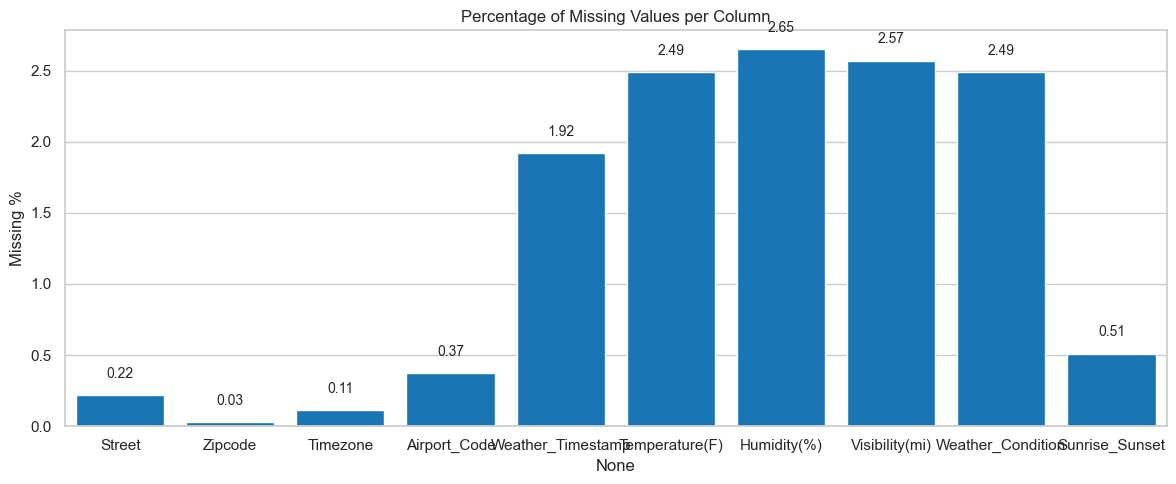

In [10]:
missing_plot = missing_percent[missing_percent > 0] 
plt.figure(figsize=(12,5))
ax = sns.barplot(x=missing_plot.index, y=missing_plot.values, color='#007acc')
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 0.1, f'{height:.2f}', 
            ha='center', va='bottom', fontsize=10)

plt.xticks(rotation=0, ha='center')
plt.ylabel('Missing %')
plt.title('Percentage of Missing Values per Column')
plt.tight_layout()
plt.show()

## Outlier Detection

In [14]:
# Detect outliers using the IQR method
Q1 = df_train[numerical_vars].quantile(0.25)
Q3 = df_train[numerical_vars].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df_train[numerical_vars] < (Q1 - 1.5 * IQR)) | 
              (df_train[numerical_vars] > (Q3 + 1.5 * IQR))).sum()

print("Number of outliers (per column):\n", outliers)

Number of outliers (per column):
 Severity          169722
Latitude               0
Longitude              0
Distance(mi)      248427
Temperature(F)     15524
Humidity(%)            0
Visibility(mi)    462310
dtype: int64


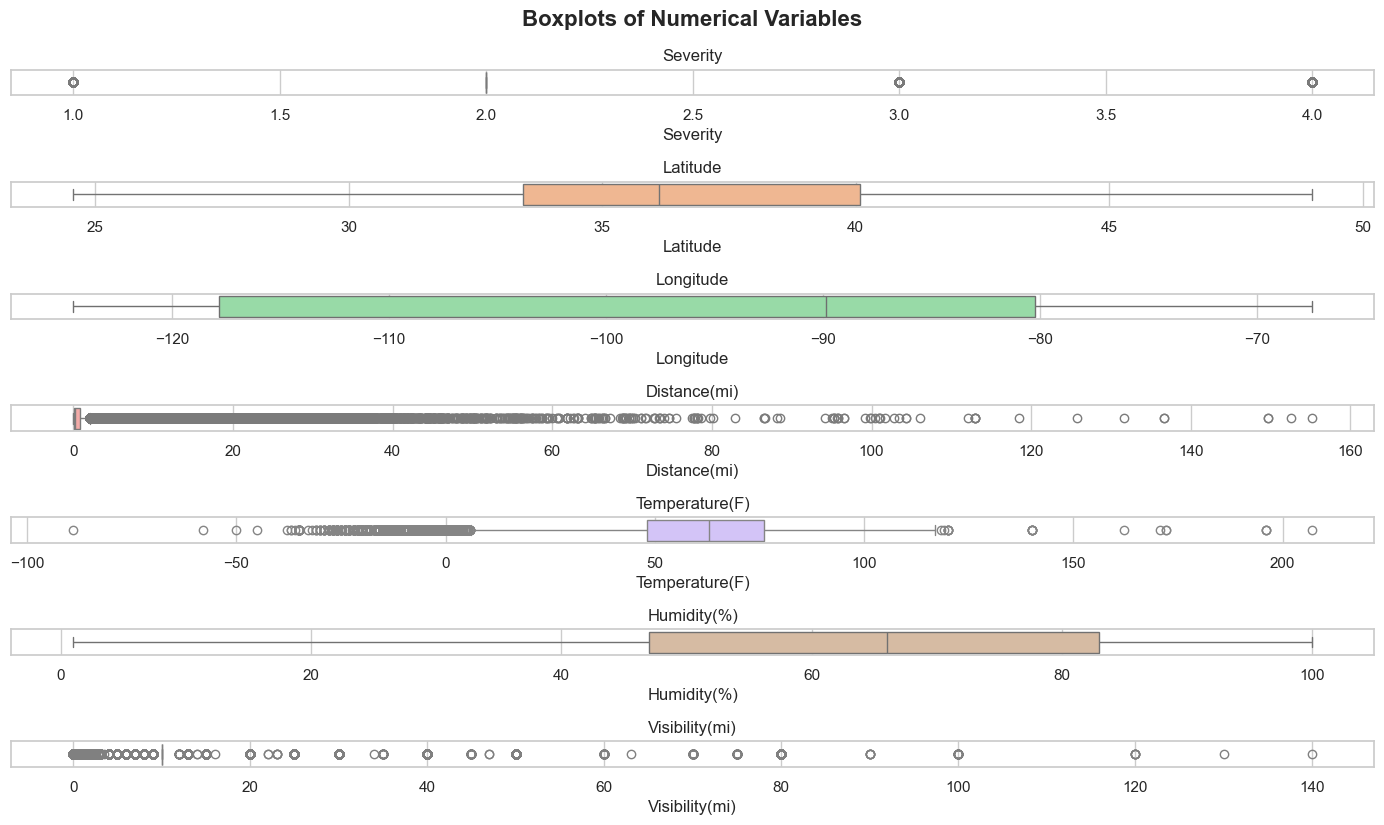

In [16]:
n = len(numerical_vars)

plt.figure(figsize=(14, n * 1.2))
plt.suptitle("Boxplots of Numerical Variables", fontsize=16, fontweight='bold')

for i, col in enumerate(numerical_vars, 1):
    plt.subplot(n, 1, i)
    sns.boxplot(
        x=df_train[col],
        orient='h',
        color=palette_color[i - 1]
    )
    plt.title(col)
    plt.tight_layout()

plt.show()

## Leakage Check

In [18]:
target_var = 'Severity'
print("Potential data leakage check:")
print("Columns highly correlated with target may indicate leakage.")
corr_target = df_train[numerical_vars].corr()[target_var].drop(target_var)
leak_cols = corr_target[abs(corr_target) > 0.9].index.tolist()
if leak_cols:
    print(f"Potential leakage columns (corr > 0.9 with target): {leak_cols}\n")
else:
    print("No obvious leakage columns detected based on correlation.\n")

Potential data leakage check:
Columns highly correlated with target may indicate leakage.
No obvious leakage columns detected based on correlation.



## VIF Check

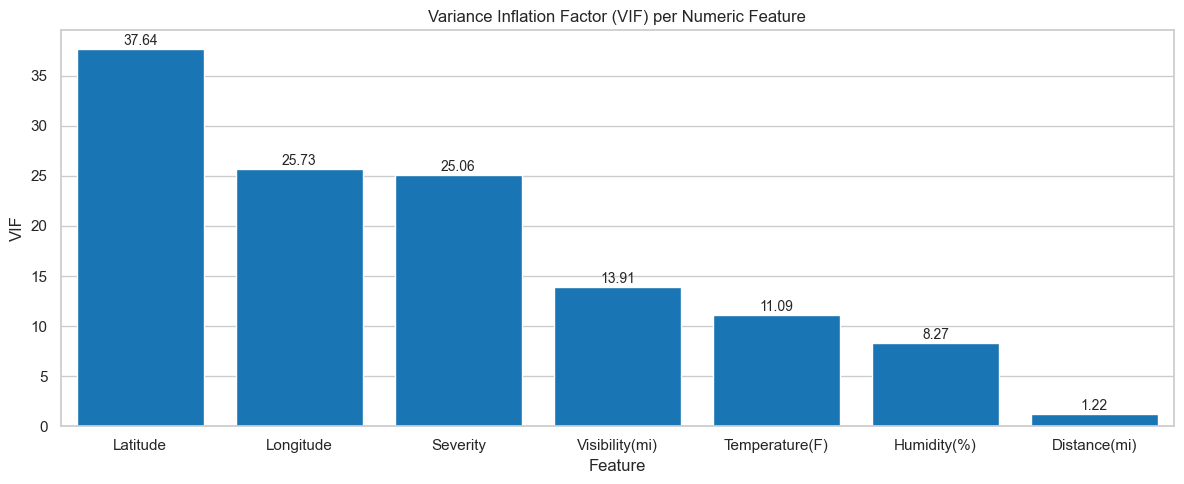

In [17]:
target_var = 'Severity'
X_numeric = df_train[numerical_vars]

vif_data = pd.DataFrame()
vif_data['Feature'] = X_numeric.columns
vif_data['VIF'] = [variance_inflation_factor(X_numeric.dropna().values, i) 
                   for i in range(X_numeric.shape[1])]
vif_data = vif_data.sort_values(by='VIF', ascending=False)

plt.figure(figsize=(12,5))
ax = sns.barplot(x='Feature', y='VIF', data=vif_data, color='#007acc')

for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 0.1, f'{height:.2f}', 
            ha='center', va='bottom', fontsize=10)
    
plt.xticks(rotation=0, ha='center')
plt.ylabel('VIF')
plt.title('Variance Inflation Factor (VIF) per Numeric Feature')
plt.tight_layout()
plt.show()

## Statistical Analysis

In [13]:
for c in categorical_vars:
    col_cnt = categorical_data[c].nunique()
    print(f"{c} has {col_cnt} unique values .")

ID has 2492196 unique values .
Start_Time has 1636474 unique values .
End_Time has 2015570 unique values .
Description has 1150710 unique values .
Street has 176406 unique values .
City has 11521 unique values .
County has 1745 unique values .
State has 49 unique values .
Zipcode has 371313 unique values .
Timezone has 4 unique values .
Airport_Code has 1968 unique values .
Weather_Timestamp has 404043 unique values .
Weather_Condition has 122 unique values .
Sunrise_Sunset has 2 unique values .


In [14]:
for i in categorical_vars:
    print (f'Value Count for {i}')
    print(df_train[i].value_counts())
    print("\n")

Value Count for ID
ID
A-5010788    1
A-4081224    1
A-4338502    1
A-4813526    1
A-6175925    1
            ..
A-7262705    1
A-5506850    1
A-4967672    1
A-7362456    1
A-7263275    1
Name: count, Length: 2492196, dtype: int64


Value Count for Start_Time
Start_Time
2021-01-26 16:16:13    181
2021-01-26 16:17:33    126
2021-02-16 06:42:43    108
2021-11-21 18:37:51     91
2021-02-16 06:43:35     72
                      ... 
2020-11-11 18:05:00      1
2021-06-20 04:18:00      1
2022-07-11 19:23:00      1
2021-07-06 07:01:56      1
2021-01-05 20:33:11      1
Name: count, Length: 1636474, dtype: int64


Value Count for End_Time
End_Time
2021-11-22 08:00:00    95
2019-10-26 09:14:51    41
2020-02-14 00:00:00    40
2020-01-25 00:00:00    35
2020-02-12 00:00:00    35
                       ..
2022-07-16 18:41:30     1
2020-03-06 09:45:33     1
2020-12-31 03:48:32     1
2023-01-14 13:23:35     1
2021-12-14 17:26:26     1
Name: count, Length: 2015570, dtype: int64


Value Count for Descrip

# **Exploratory Data Analysis**

## Numerical features distribution

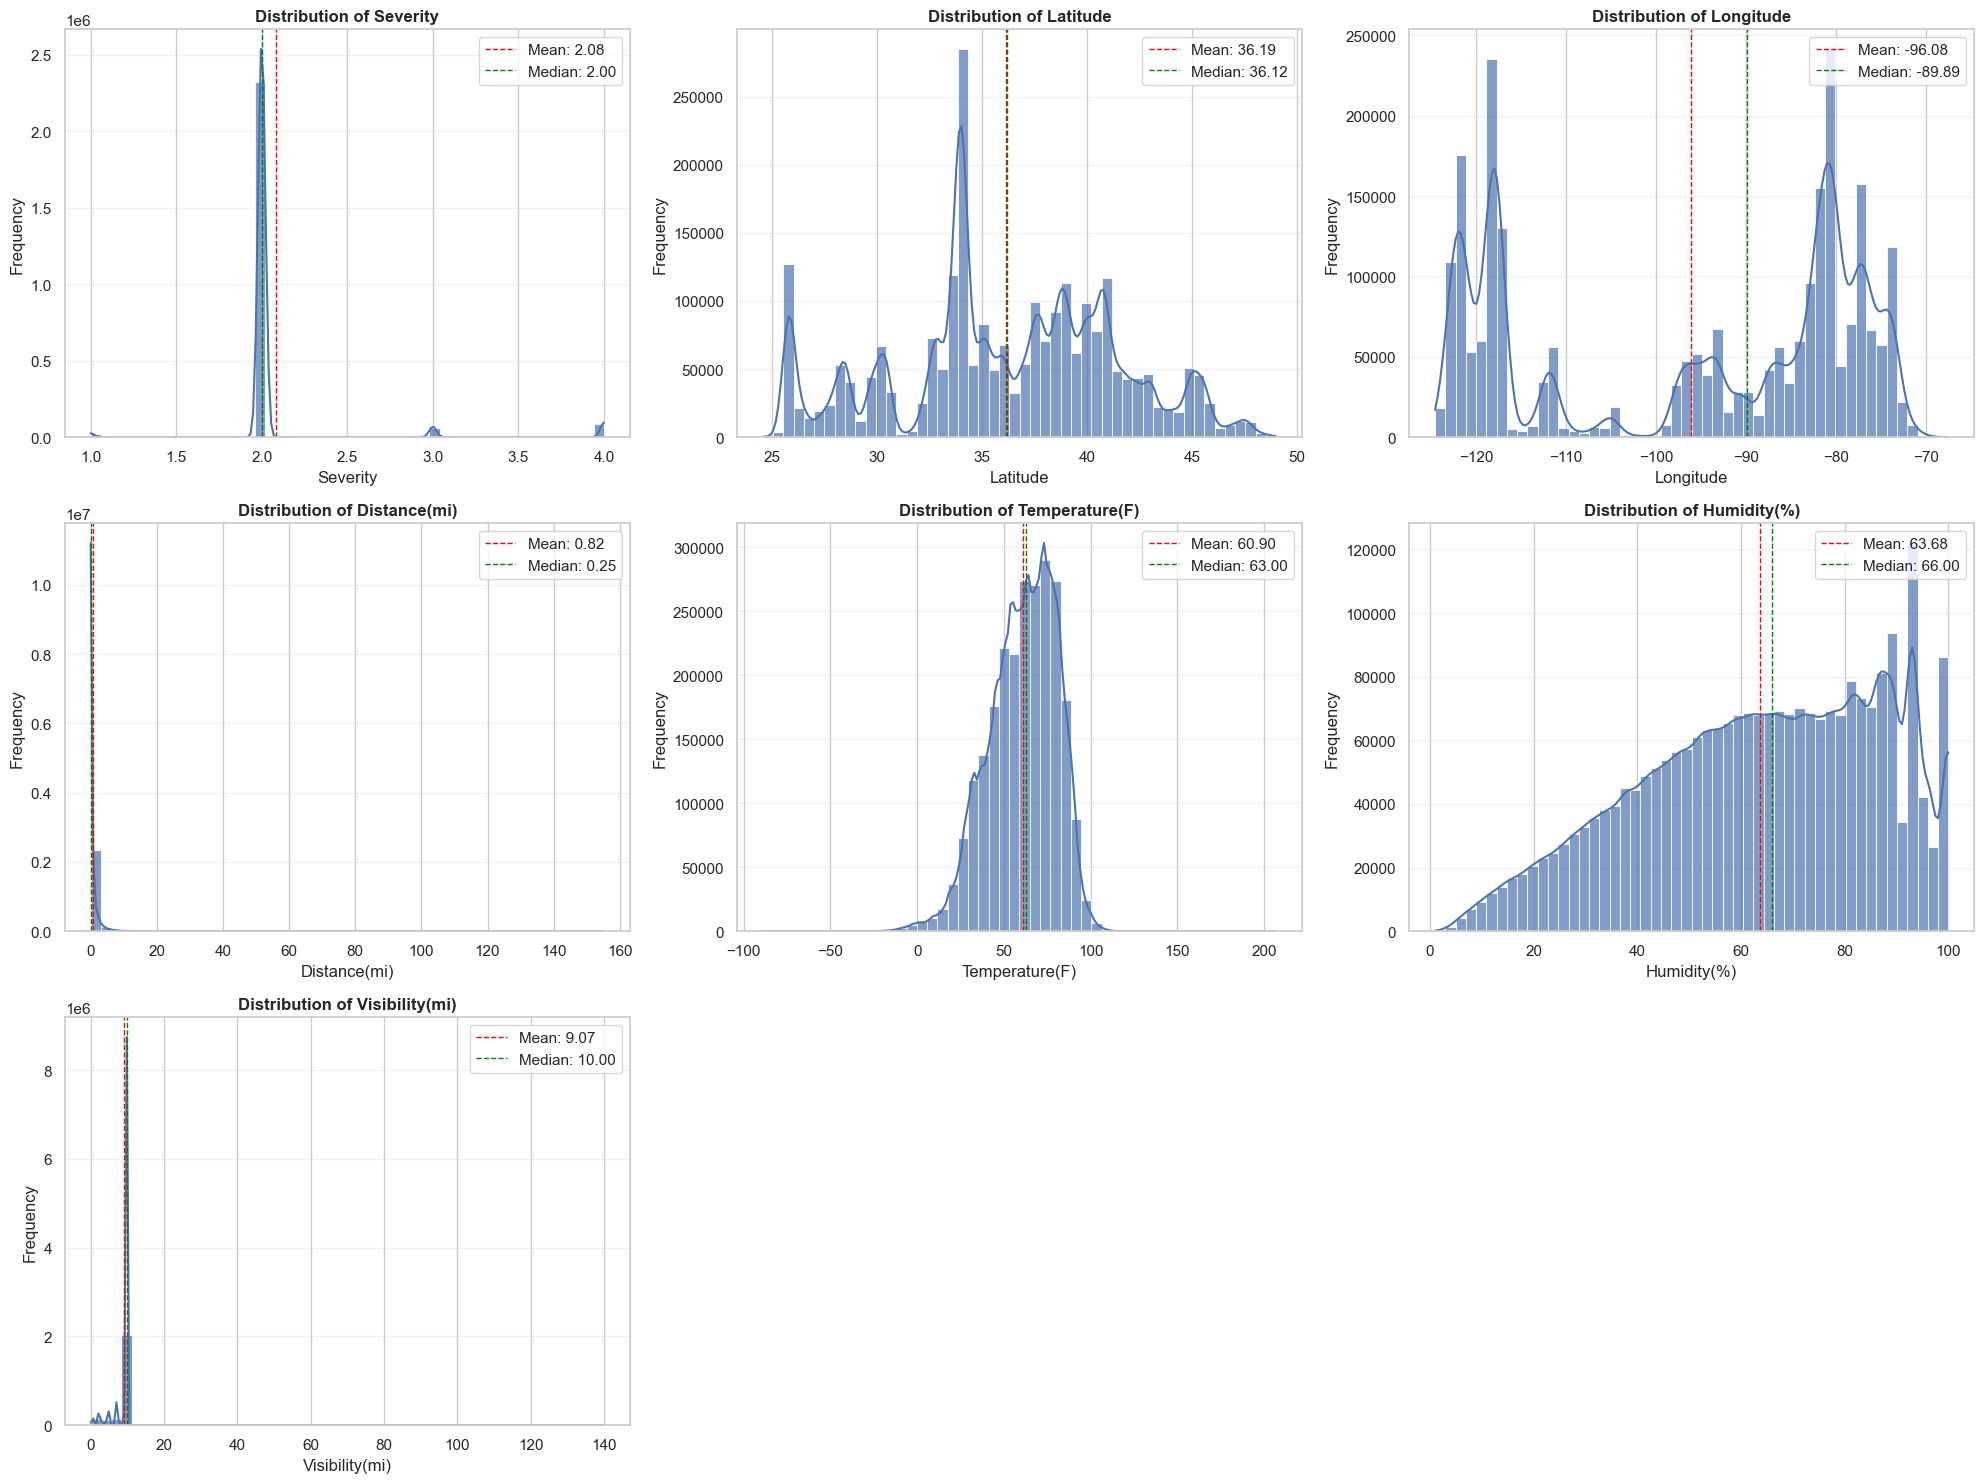

In [15]:
numerical_cols = df_train.select_dtypes(include=['int64', 'float64']).columns

n_cols = len(numerical_cols)
n_rows = (n_cols + 2) // 3

fig, axes = plt.subplots(n_rows, 3, figsize=(20, n_rows * 5))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    if idx < len(axes):
        sns.histplot(df_train[col], kde=True, bins=50, ax=axes[idx], alpha=0.7)
        axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')
        axes[idx].grid(axis='y', alpha=0.3)
        
        # Add mean and median lines
        axes[idx].axvline(df_train[col].mean(), color='red', linestyle='--', linewidth=1, label=f'Mean: {df_train[col].mean():.2f}')
        axes[idx].axvline(df_train[col].median(), color='green', linestyle='--', linewidth=1, label=f'Median: {df_train[col].median():.2f}')

        axes[idx].legend(loc='upper right')

for idx in range(len(numerical_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## Categorical features distribution

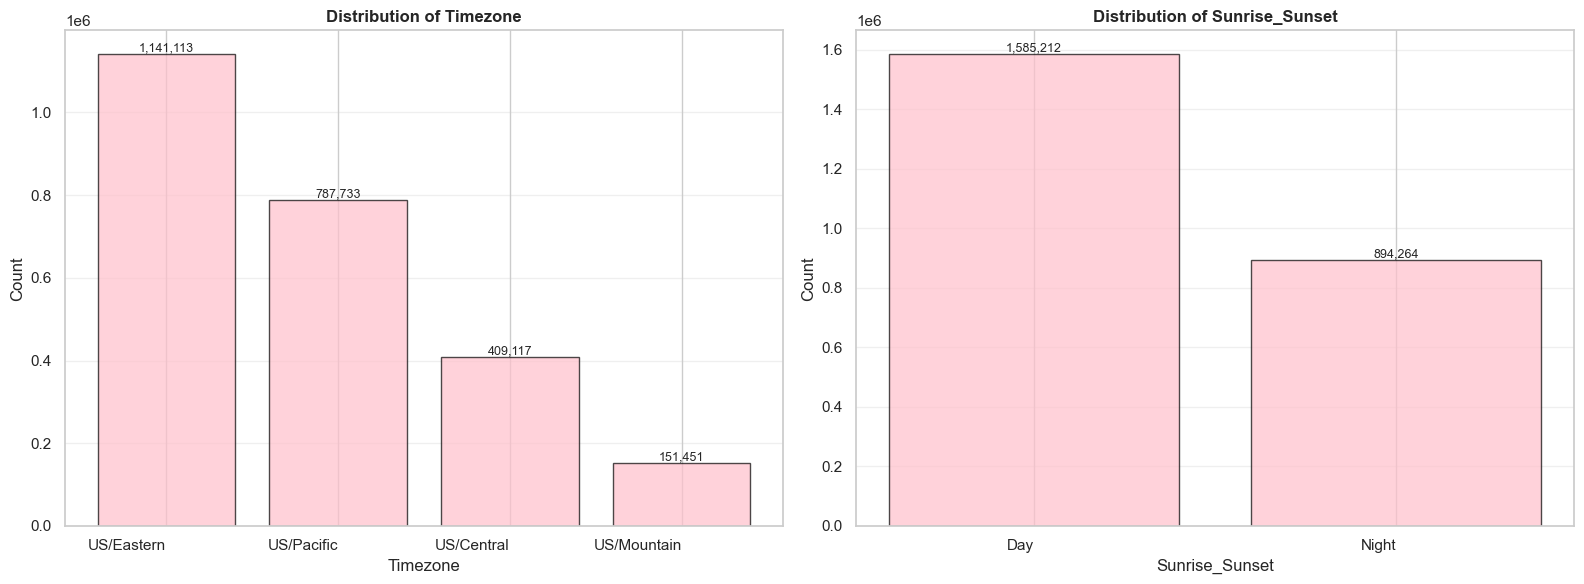

In [16]:
categorical_cols = df_train.select_dtypes(include=['object']).columns.drop(['ID', 'Start_Time', 'End_Time', 'Description', 'Street', 'Zipcode', 'Weather_Timestamp', 'City', 'County', 'State', 'Airport_Code', 'Weather_Condition'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    if idx < len(axes):
        value_counts = df_train[col].value_counts()
        axes[idx].bar(range(len(value_counts)), value_counts.values, color='pink', edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Count')
        axes[idx].set_xticks(range(len(value_counts)))
        axes[idx].set_xticklabels(value_counts.index, rotation=0, ha='right')
        axes[idx].grid(axis='y', alpha=0.3)
        
        for i, v in enumerate(value_counts.values):
            axes[idx].text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)

# Hide extra subplots
for idx in range(len(categorical_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

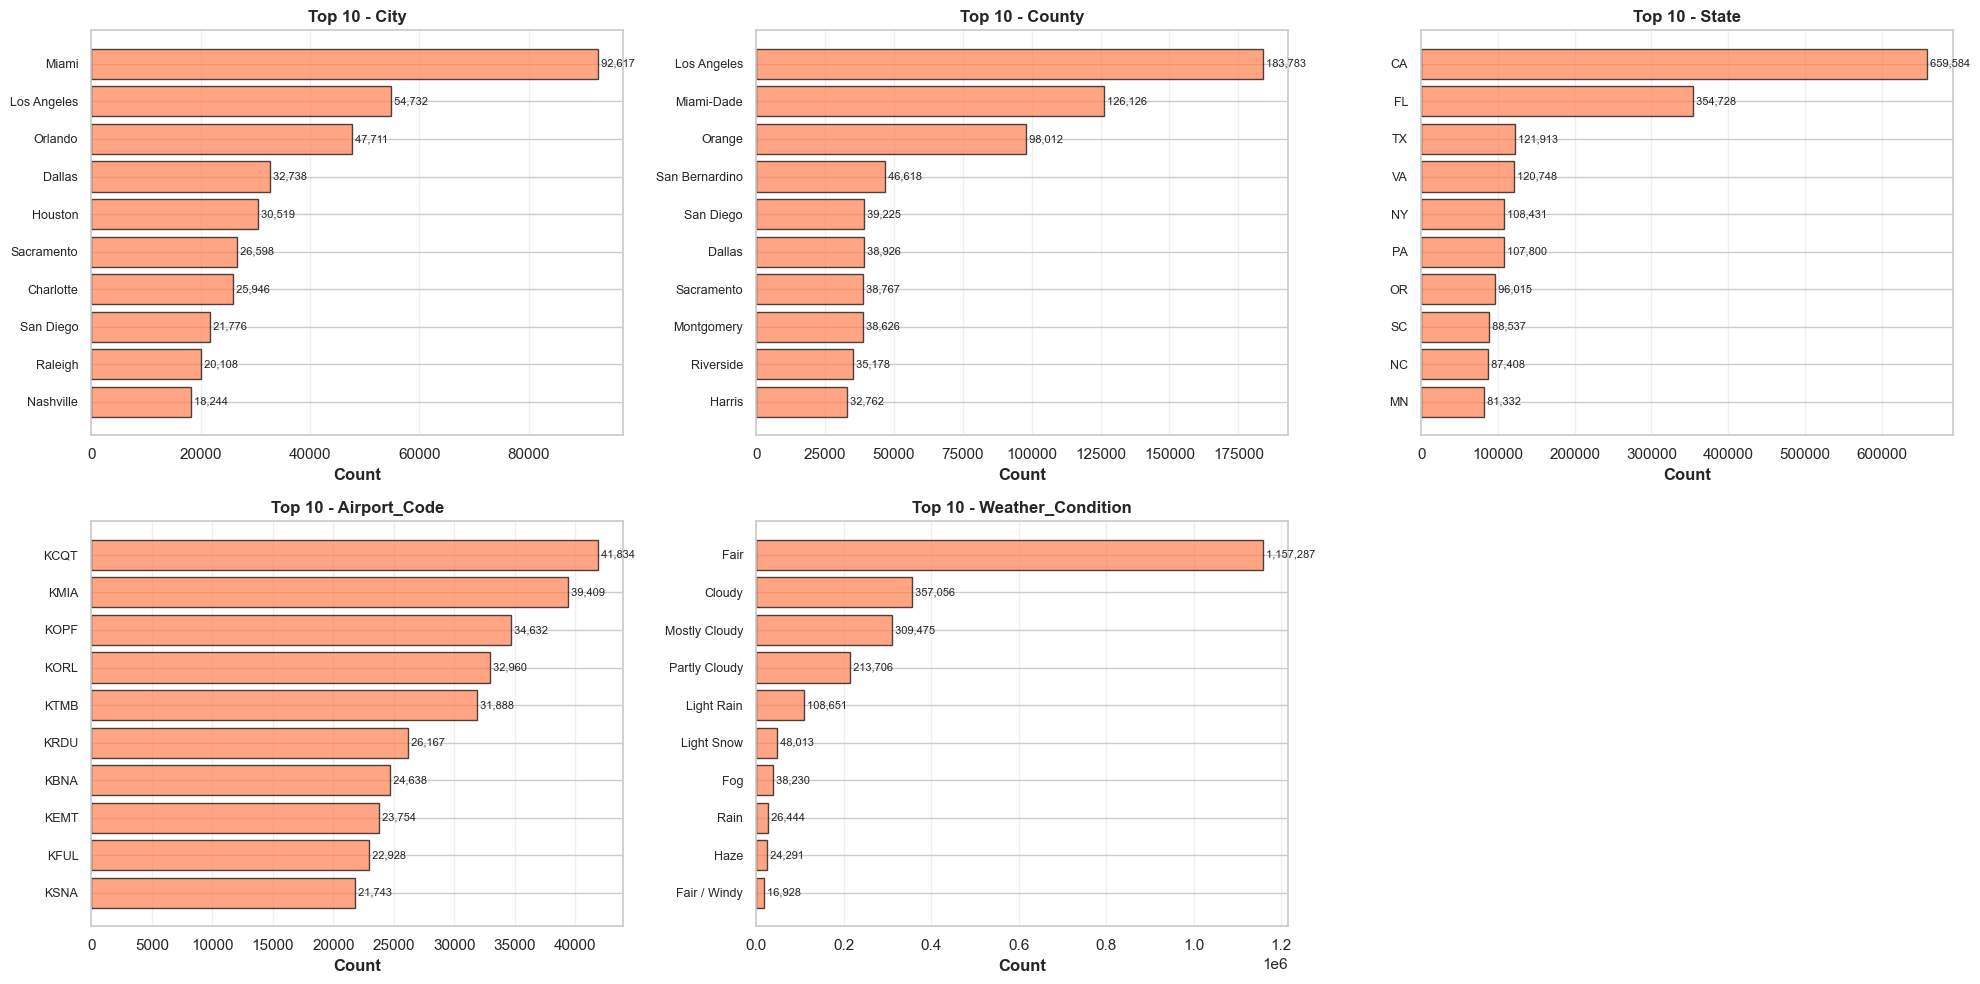

In [17]:
high_cardinality_cols = ['City', 'County', 'State', 'Airport_Code', 'Weather_Condition']

n_cols = len(high_cardinality_cols)
n_rows = (n_cols + 2) // 3

fig, axes = plt.subplots(n_rows, 3, figsize=(20, n_rows * 5))
axes = axes.flatten()

for idx, col in enumerate(high_cardinality_cols):
    if idx < len(axes):
        value_counts = df_train[col].value_counts().head(10)
        
        value_counts = value_counts.iloc[::-1]
        
        axes[idx].barh(range(len(value_counts)), value_counts.values, 
                      color='coral', edgecolor='black', alpha=0.7)
        axes[idx].set_yticks(range(len(value_counts)))
        axes[idx].set_yticklabels(value_counts.index, fontsize=9)
        axes[idx].set_title(f'Top 10 - {col}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Count', fontweight='bold')
        axes[idx].grid(axis='x', alpha=0.3)
        
        for i, v in enumerate(value_counts.values):
            axes[idx].text(v, i, f' {v:,}', va='center', fontsize=8)

for idx in range(len(high_cardinality_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## Numerical Features vs Severity

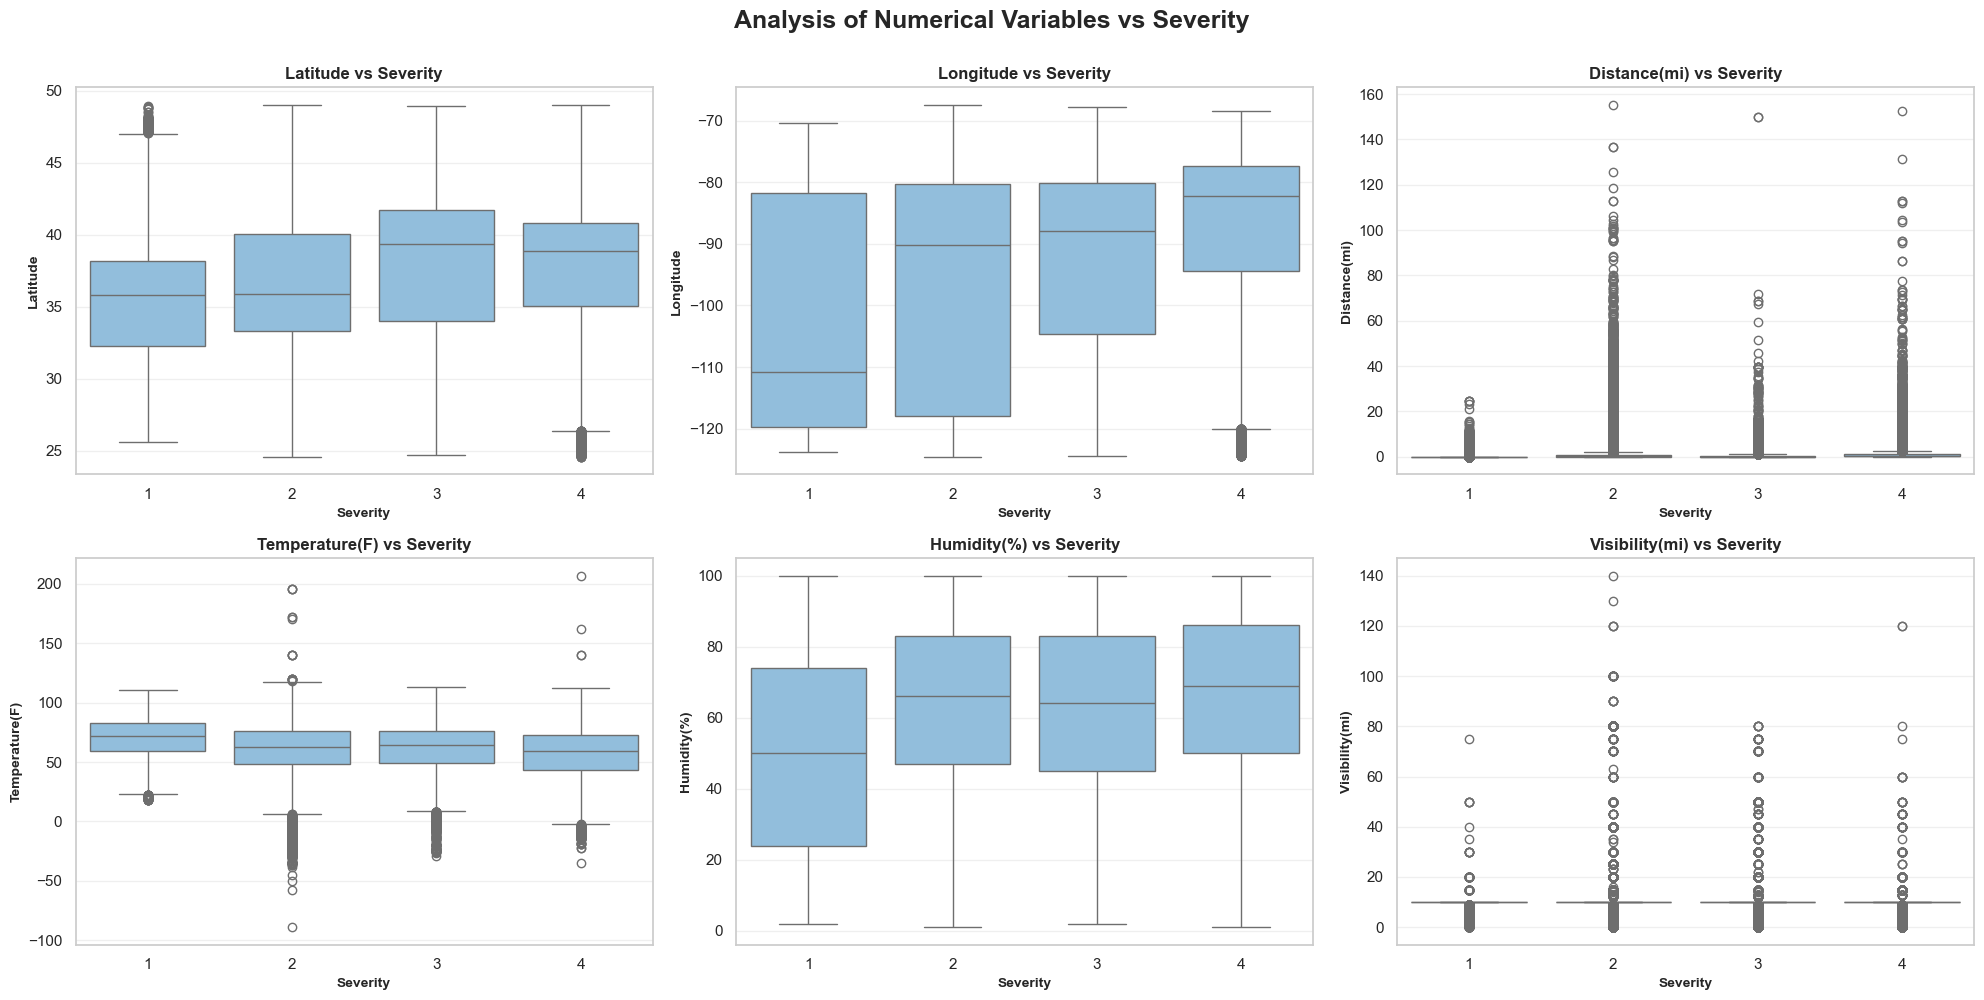

In [18]:
numerical_cols_for_analysis = df_train.select_dtypes(include=['int64', 'float64']).columns.drop(['Severity']).tolist()

n_cols = len(numerical_cols_for_analysis)
n_rows = (n_cols + 2) // 3

fig, axes = plt.subplots(n_rows, 3, figsize=(20, n_rows * 5))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols_for_analysis):
    if idx < len(axes):
        sns.boxplot(data=df_train, x='Severity', y=col, 
                    ax=axes[idx], 
                    color='#85C1E9',
                    showfliers=True) 
        
        axes[idx].set_title(f'{col} vs Severity', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Severity', fontweight='bold', fontsize=10)
        axes[idx].set_ylabel(col, fontweight='bold', fontsize=10)
        axes[idx].grid(axis='y', alpha=0.3)

# Hide extra subplots
for idx in range(len(numerical_cols_for_analysis), len(axes)):
    axes[idx].axis('off')
    
plt.suptitle('Analysis of Numerical Variables vs Severity', 
             fontsize=18, fontweight='bold', y=0.998)
plt.tight_layout()
plt.show()

## Categorical Features vs Severity

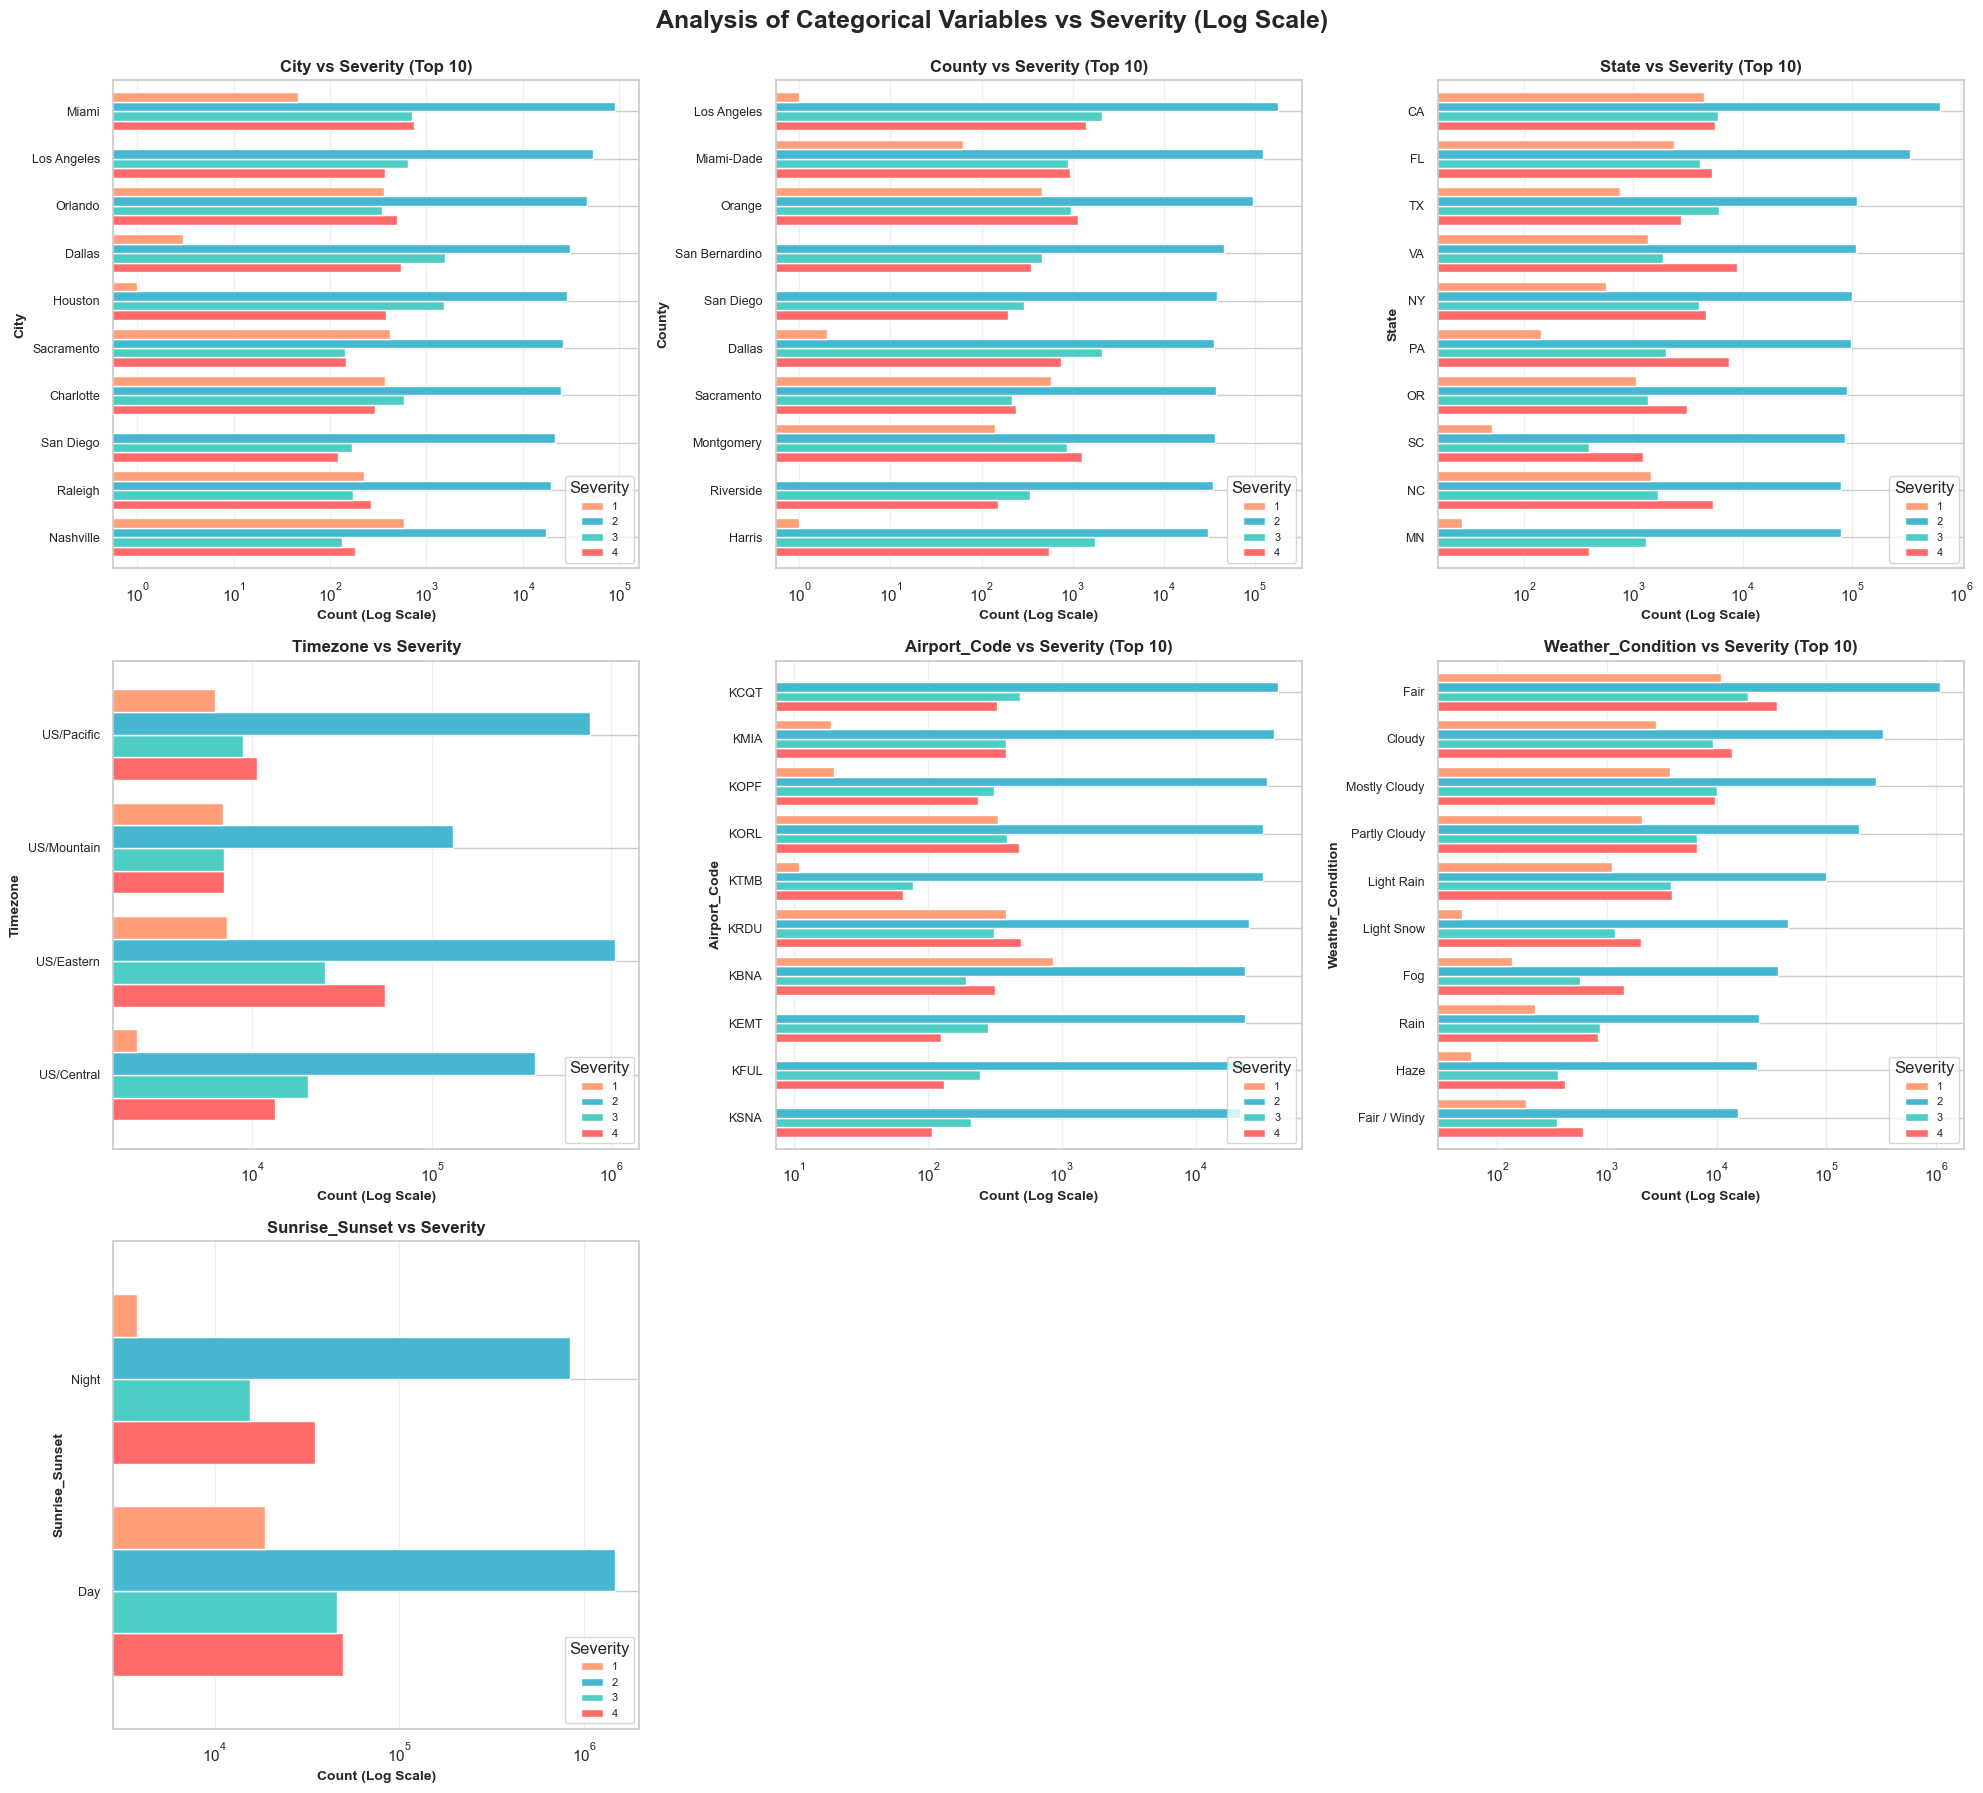

In [19]:
categorical_cols_for_analysis = df_train.select_dtypes(include=['object']).columns.drop(['ID', 'Start_Time', 'End_Time', 'Description', 'Street', 'Zipcode', 'Weather_Timestamp']).tolist()

n_cols = len(categorical_cols_for_analysis)
n_rows = (n_cols + 2) // 3

fig, axes = plt.subplots(n_rows, 3, figsize=(20, n_rows * 6)) 
axes = axes.flatten()

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

for idx, feature in enumerate(categorical_cols_for_analysis):
    if idx < len(axes):
        if df_train[feature].nunique() > 10:
            top_categories = df_train[feature].value_counts().head(10).index
            top_categories = top_categories[::-1]
            plot_df = df_train[df_train[feature].isin(top_categories)]
            title_suffix = ' (Top 10)'
        else:
            plot_df = df_train
            title_suffix = ''
        
        severity_counts = plot_df.groupby([feature, 'Severity']).size().unstack(fill_value=0)

        if df_train[feature].nunique() > 10:
             severity_counts = severity_counts.reindex(top_categories)
        
        severity_counts = severity_counts.reindex(columns=[1, 2, 3, 4], fill_value=0)
        severity_counts = severity_counts[[4, 3, 2, 1]]

        severity_counts.plot(kind='barh', ax=axes[idx], stacked=False, 
                             logx=True, width=0.8,
                             color=colors)
        
        axes[idx].set_title(f'{feature} vs Severity{title_suffix}', fontsize=12, fontweight='bold')
        axes[idx].set_ylabel(feature, fontweight='bold', fontsize=10)
        axes[idx].set_xlabel('Count (Log Scale)', fontweight='bold', fontsize=10)
        axes[idx].tick_params(axis='y', labelsize=9)

        handles, labels = axes[idx].get_legend_handles_labels()
        axes[idx].legend(handles[::-1], labels[::-1], title='Severity', fontsize=8, loc='lower right')
        
        axes[idx].grid(axis='x', alpha=0.3)

# Hide extra subplot
for i in range(len(categorical_cols_for_analysis), len(axes)):
    axes[i].axis('off')

plt.suptitle('Analysis of Categorical Variables vs Severity (Log Scale)', 
             fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

## Correlation Matrix

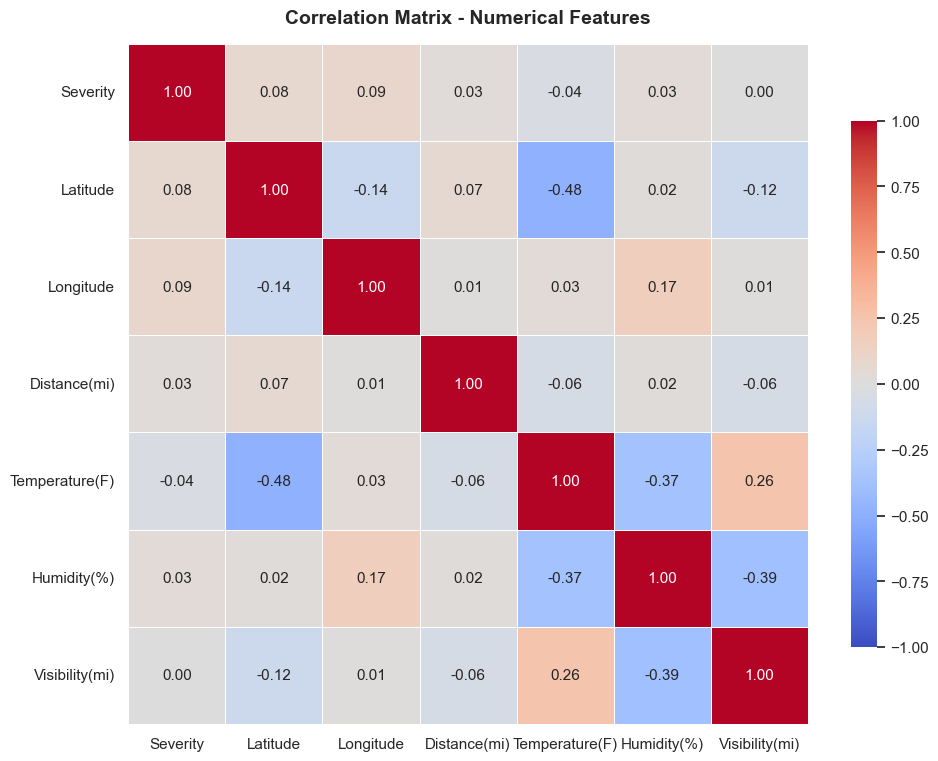

Highly Correlated Feature Pairs (|correlation| > 0.7)

No feature pairs with |correlation| > 0.7 found.


In [23]:
numerical_cols = df_train.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df_train[numerical_cols].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm', 
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.75},
            vmin=-1, vmax=1,
            annot_kws={"size": 11})

plt.title('Correlation Matrix - Numerical Features', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=0, ha='center')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("Highly Correlated Feature Pairs (|correlation| > 0.7)")

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append((
                corr_matrix.columns[i], 
                corr_matrix.columns[j], 
                corr_matrix.iloc[i, j]
            ))

if high_corr_pairs:
    for var1, var2, corr in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f"{var1:30s} <-> {var2:30s} : {corr:7.3f}")
else:
    print("\nNo feature pairs with |correlation| > 0.7 found.")

## **Build Baseline Model**

In [20]:
target_var = 'Severity'
y = df_train[target_var]
X = df_train.drop(columns=[target_var])

In [21]:
model_results = {}

In [22]:
drop_cols = [
    'ID','Start_Time','End_Time','Description','Street','City','County','State',
    'Zipcode','Timezone','Airport_Code','Weather_Timestamp','Weather_Condition','Sunrise_Sunset'
]

X_model = X.drop(columns=drop_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X_model, y, test_size=0.2, random_state=42
)

In [23]:
X_train_clean = X_train.dropna()
y_train_clean = y_train[X_train_clean.index]

X_test_clean = X_test.dropna()
y_test_clean = y_test[X_test_clean.index]

models_to_evaluate = {
    'XGBoost': {
        'model': XGBRegressor(
            n_estimators=100,
            max_depth=5,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            verbosity=0
        ),
        'use_clean': False 
    },
    'LightGBM': {
        'model': LGBMRegressor(
            n_estimators=100,
            max_depth=5,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            verbose=-1
        ),
        'use_clean': False
    },
    'Random Forest': {
        'model': RandomForestRegressor(
            n_estimators=100,
            max_depth=10,
            random_state=42,
            n_jobs=-1
        ),
        'use_clean': True  
    },
    'CatBoost': {
        'model': CatBoostRegressor(
            n_estimators=50,
            random_state=42,
            verbose=0
        ),
        'use_clean': True  
    }
}

model_results = []

def evaluate_and_store(model, X_test, y_test, name):
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mse = mean_squared_error(y_test, pred)
    rmlse = np.sqrt(mean_squared_log_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    model_results.append({
        "Model": name,
        "RMSE": rmse,
        "RMLSE": rmlse,
        "MSE": mse,
        "R2": r2
    })

for name, cfg in models_to_evaluate.items():
    print(f"Training {name}...")
    model = cfg['model']
    
    if cfg.get('use_clean', False):
        model.fit(X_train_clean, y_train_clean)
        evaluate_and_store(model, X_test_clean, y_test_clean, name)
    else:
        model.fit(X_train, y_train)
        evaluate_and_store(model, X_test, y_test, name)

results_df = pd.DataFrame(model_results)
print("\nModel Evaluation Results:")
print(results_df.sort_values(by='RMSE'))


Training XGBoost...
Training LightGBM...
Training Random Forest...
Training CatBoost...

Model Evaluation Results:
           Model      RMSE     RMLSE       MSE        R2
2  Random Forest  0.379298  0.102062  0.143867  0.119262
3       CatBoost  0.380846  0.102613  0.145044  0.112057
1       LightGBM  0.383945  0.103243  0.147413  0.104721
0        XGBoost  0.384437  0.103413  0.147792  0.102422
